<a href="https://colab.research.google.com/github/Mr-Zainulabadin/python_programing/blob/main/modified_ga_feature_selection_paper_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modified Paper Implementation using Genetic Algorithm Feature Selection

This notebook implements the modified methodology of the paper using:
- Genetic Algorithm based Feature Selection
- Decision Tree
- Random Forest
- Naive Bayes

# INSTALL LIBRARIES

In [1]:


!pip install sklearn-genetic kagglehub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 20.8 MB/s eta 0:00:00


# IMPORT LIBRARIES

In [2]:




import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from genetic_selection import GeneticSelectionCV


## Download Dataset

In [3]:
path = kagglehub.dataset_download(
    "uciml/pima-indians-diabetes-database"
)

csv_path = os.path.join(path, "diabetes.csv")

df = pd.read_csv(csv_path)

print(df.head())
print(df.shape)


Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
(768, 9)


## Data Preprocessing

In [4]:
cols = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

# Replace 0 with NaN
df[cols] = df[cols].replace(0, np.nan)

# Median Imputation
imputer = SimpleImputer(strategy='median')

df[cols] = imputer.fit_transform(df[cols])

print(df.isnull().sum())


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## Features and Target

In [5]:
X = df.drop("Outcome", axis=1)

y = df["Outcome"]


## Genetic Algorithm Feature Selection

In [6]:
!pip install sklearn-genetic-opt

In [7]:
from sklearn_genetic import GAFeatureSelectionCV

In [8]:

# FEATURES AND TARGET


X = df.drop("Outcome", axis=1)

y = df["Outcome"]

# BASE ESTIMATOR

estimator = RandomForestClassifier(
    n_estimators=100,
    random_state=1
)


# GENETIC ALGORITHM FEATURE SELECTION


evolved_estimator = GAFeatureSelectionCV(
    estimator=estimator,

    cv=5, #5-fold cross validatio

    scoring="accuracy",

    population_size=30,  #30 different feature combinations

    generations=10,

    crossover_probability=0.5,  #2 parent solutions

    mutation_probability=0.2,

    n_jobs=-1
)

# TRAIN GA

evolved_estimator.fit(X, y)


# SELECTED FEATURES


selected_features = X.columns[
    evolved_estimator.support_ #support tell which is selected return bolean
]

print("Selected Features:")
print(selected_features)


# NEW DATASET


X_selected = X[selected_features]

/usr/local/lib/python3.12/dist-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	30    	0.695172	0.0544781  	0.766981   	0.580783   
1  	39    	0.735203	0.023317   	0.766981   	0.653595   
2  	43    	0.750083	0.00799332 	0.766981   	0.731788   
3  	51    	0.758592	0.00513561 	0.768296   	0.75003    
4  	44    	0.764422	0.00521146 	0.779985   	0.756523   
5  	44    	0.766202	0.00474379 	0.779985   	0.757864   
6  	45    	0.768459	0.00502337 	0.779985   	0.757864   
7  	37    	0.773965	0.00603362 	0.779985   	0.766981   
8  	39    	0.778816	0.00350649 	0.779985   	0.768296   
9  	44    	0.779595	0.00209812 	0.779985   	0.768296   
10 	44    	0.779985	0          	0.779985   	0.779985   
Selected Features:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'BMI',
       'DiabetesPedigreeFunction', 'Age'],
      dtype='object')


## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y  #equal distribution
)


## Evaluation Function

In [10]:
def calculate_metrics(model_name, y_test, y_pred, y_prob):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    auc = roc_auc_score(y_test, y_prob)

    return {
        "Model": model_name,
        "Accuracy": round(accuracy*100,2),
        "Precision": round(precision*100,2),
        "Recall": round(recall*100,2),
        "Specificity": round(specificity*100,2),
        "F1 Score": round(f1*100,2),
        "AUC": round(auc*100,2)
    }


## Decision Tree Algorithm

In [11]:

# DECISION TREE


dt_model = DecisionTreeClassifier(
    criterion='entropy',  #disorder measure clearly make tree
    random_state=1
)

# Train
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Probability
dt_prob = dt_model.predict_proba(X_test)[:,1] #class 1 probability

# Results
dt_results = calculate_metrics(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

print(dt_results)


{'Model': 'Decision Tree', 'Accuracy': 74.03, 'Precision': 64.38, 'Recall': 58.02, 'Specificity': np.float64(82.67), 'F1 Score': 61.04, 'AUC': np.float64(70.35)}


In [25]:
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=1
)

In [26]:
# Train
dt_model.fit(X_train, y_train)

# Prediction
dt_pred = dt_model.predict(X_test)

# Probability
dt_prob = dt_model.predict_proba(X_test)[:,1] #class 1 probability

# Results
dt_results = calculate_metrics(
    "Decision Tree",
    y_test,
    dt_pred,
    dt_prob
)

print(dt_results)

{'Model': 'Decision Tree', 'Accuracy': 74.03, 'Precision': 64.38, 'Recall': 58.02, 'Specificity': np.float64(82.67), 'F1 Score': 61.04, 'AUC': np.float64(70.35)}


## Random Forest Algorithm

In [12]:


rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=1
)

# Train
rf_model.fit(X_train, y_train)

# Prediction
rf_pred = rf_model.predict(X_test)

# Probability
rf_prob = rf_model.predict_proba(X_test)[:,1]

# Results
rf_results = calculate_metrics(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

print(rf_results)


{'Model': 'Random Forest', 'Accuracy': 73.59, 'Precision': 64.29, 'Recall': 55.56, 'Specificity': np.float64(83.33), 'F1 Score': 59.6, 'AUC': np.float64(80.61)}


## Naive Bayes Algorithm

In [13]:


nb_model = GaussianNB()

# Train
nb_model.fit(X_train, y_train)

# Prediction
nb_pred = nb_model.predict(X_test)

# Probability
nb_prob = nb_model.predict_proba(X_test)[:,1]

# Results
nb_results = calculate_metrics(
    "Naive Bayes",
    y_test,
    nb_pred,
    nb_prob
)

print(nb_results)


{'Model': 'Naive Bayes', 'Accuracy': 72.73, 'Precision': 61.54, 'Recall': 59.26, 'Specificity': np.float64(80.0), 'F1 Score': 60.38, 'AUC': np.float64(79.02)}


## Final Comparison Table

In [14]:
results_df = pd.DataFrame([
    dt_results,
    rf_results,
    nb_results
])

print(results_df.to_string(index=False))


        Model  Accuracy  Precision  Recall  Specificity  F1 Score   AUC
Decision Tree     74.03      64.38   58.02        82.67     61.04 70.35
Random Forest     73.59      64.29   55.56        83.33     59.60 80.61
  Naive Bayes     72.73      61.54   59.26        80.00     60.38 79.02


In [28]:
from sklearn.metrics import classification_report

print("\n"+"="*90)
print("CLASSIFICATION REPORTS - GA WRAPPER FEATURE SELECTION")
print("="*90)

print("\nDecision Tree (GA):")
print(classification_report(y_test, dt_pred))

print("\nRandom Forest (GA):")
print(classification_report(y_test, rf_pred))

print("\nNaive Bayes (GA):")
print(classification_report(y_test, nb_pred))

print("\n"+"="*90)
print("CLASSIFICATION REPORTS - EMBEDDED FEATURE SELECTION")
print("="*90)

print("\nDecision Tree (Embedded):")
print(classification_report(y_test_emb, dt_pred_emb))

print("\nRandom Forest (Embedded):")
print(classification_report(y_test_emb, rf_pred_emb))

print("\nNaive Bayes (Embedded):")
print(classification_report(y_test_emb, nb_pred_emb))


CLASSIFICATION REPORTS - GA WRAPPER FEATURE SELECTION

Decision Tree (GA):
              precision    recall  f1-score   support

           0       0.78      0.83      0.81       150
           1       0.64      0.58      0.61        81

    accuracy                           0.74       231
   macro avg       0.71      0.70      0.71       231
weighted avg       0.74      0.74      0.74       231


Random Forest (GA):
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       150
           1       0.64      0.56      0.60        81

    accuracy                           0.74       231
   macro avg       0.71      0.69      0.70       231
weighted avg       0.73      0.74      0.73       231


Naive Bayes (GA):
              precision    recall  f1-score   support

           0       0.78      0.80      0.79       150
           1       0.62      0.59      0.60        81

    accuracy                           0.73       231
   macro avg

## Accuracy Comparison Graph

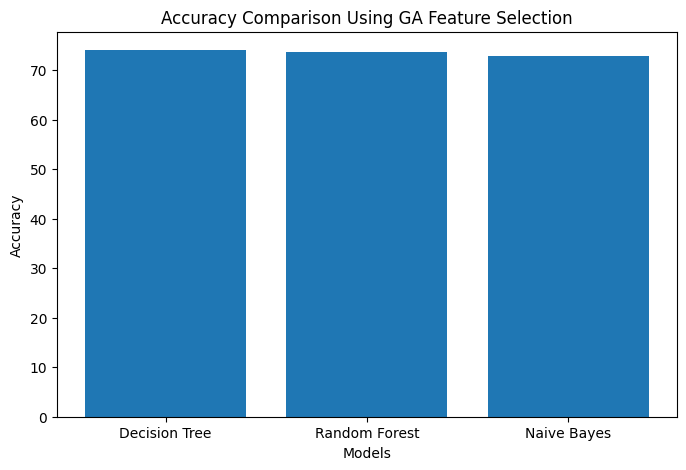

In [15]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.title("Accuracy Comparison Using GA Feature Selection")

plt.show()


# Comparison with Original Paper

The original paper used PCA, k-means clustering, and feature importance ranking for feature selection. In this implementation, the feature selection stage was replaced with a Genetic Algorithm (GA)-based wrapper feature selection approach while keeping the same machine learning classifiers (Decision Tree, Random Forest, and Naive Bayes) used in the original paper.

The Genetic Algorithm searches for the optimal subset of features using evolutionary operations such as mutation, crossover, and selection. This approach can improve model generalization and optimize feature subsets directly based on classification performance.

The results may differ from the original paper due to:
- Different feature subsets selected by GA
- Randomness in genetic algorithms
- Different train-test split behavior
- Differences between sklearn implementation and original R implementation
- Wrapper-based optimization of features




COMPARISON BETWEEN ORIGINAL PAPER AND GA FEATURE SELECTION
        Model  Paper Accuracy  My Accuracy
Decision Tree           72.29        74.03
Random Forest           74.46        73.59
  Naive Bayes           72.29        72.73


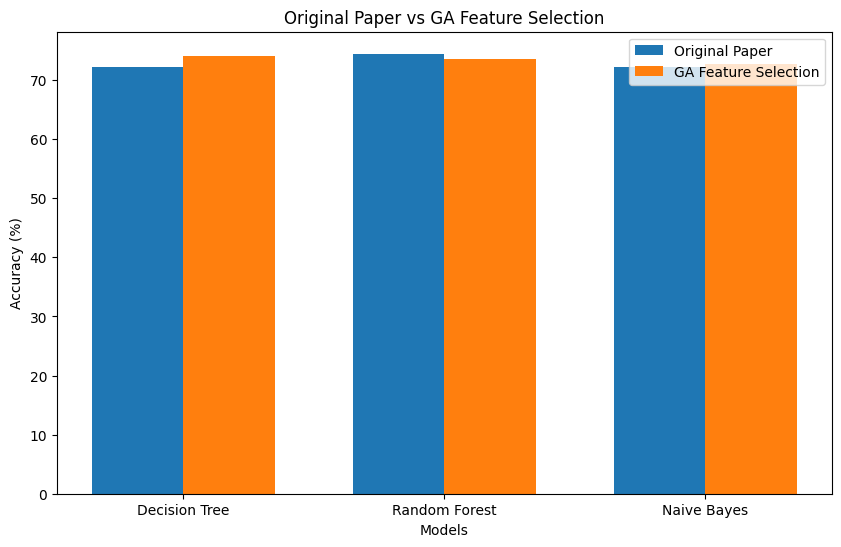

In [ ]:
# ============================================================
# COMPARISON BETWEEN PAPER RESULTS AND GA RESULTS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# PAPER RESULTS (FROM ORIGINAL IMPLEMENTATION)
# ============================================================

paper_results = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest",
        "Naive Bayes"
    ],

    "Paper Accuracy": [
        72.29,
        74.46,
        72.29
    ]
})

# ============================================================
# MY RESULTS (GA FEATURE SELECTION)
# ============================================================

# results_df contains your GA results

my_results = results_df[[
    "Model",
    "Accuracy"
]]

my_results.columns = [
    "Model",
    "My Accuracy"
]

# ============================================================
# MERGE RESULTS
# ============================================================

comparison_df = pd.merge(
    paper_results,
    my_results,
    on="Model"
)

# ============================================================
# DISPLAY TABLE
# ============================================================

print("\n")
print("="*90)
print("COMPARISON BETWEEN ORIGINAL PAPER AND GA FEATURE SELECTION")
print("="*90)

print(comparison_df.to_string(index=False))

# ============================================================
# BAR GRAPH
# ============================================================

models = comparison_df["Model"]

paper_acc = comparison_df["Paper Accuracy"]

my_acc = comparison_df["My Accuracy"]

x = np.arange(len(models))

width = 0.35

plt.figure(figsize=(10,6))

# Paper Results
plt.bar(
    x - width/2,
    paper_acc,
    width,
    label='Original Paper'
)

# GA Results
plt.bar(
    x + width/2,
    my_acc,
    width,
    label='GA Feature Selection'
)

# Labels
plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.title("Original Paper vs GA Feature Selection")

plt.xticks(x, models)

plt.legend()

plt.show()

# embaded

In [16]:
from sklearn.feature_selection import SelectFromModel

# EMBEDDED FEATURE SELECTION

In [29]:
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel

In [30]:
import numpy as np

cols_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]

df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [31]:
imputer = SimpleImputer(strategy='median')

X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

In [32]:
embedded_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=100,
        criterion='entropy',
        random_state=1
    )
)

embedded_selector.fit(X_imputed, y)

SelectFromModel(estimator=RandomForestClassifier(criterion='entropy',
                                                 random_state=1))

In [33]:
embedded_features = X.columns[
    embedded_selector.get_support()
]

print("Embedded Selected Features:")
print(embedded_features)

Embedded Selected Features:
Index(['Glucose', 'BMI', 'Age'], dtype='object')


new dataset

In [34]:
X_embedded = X[embedded_features]

In [35]:
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embedded,
    y,
    test_size=0.30,
    random_state=1,
    stratify=y
)

# DECISION TREE - EMBEDDED

In [37]:
# ============================================================
# J48-LIKE DECISION TREE (EMBEDDED)
# ============================================================

from sklearn.tree import DecisionTreeClassifier

dt_model_emb = DecisionTreeClassifier(

    criterion='entropy',      # Information Gain like J48

    splitter='best',

    max_depth=None,

    min_samples_split=2,

    min_samples_leaf=1,

    random_state=1
)

# ============================================================
# TRAIN MODEL
# ============================================================

dt_model_emb.fit(X_train_emb, y_train_emb)

# ============================================================
# PREDICTIONS
# ============================================================

dt_pred_emb = dt_model_emb.predict(X_test_emb)

# ============================================================
# PROBABILITY
# ============================================================

dt_prob_emb = dt_model_emb.predict_proba(X_test_emb)[:,1]

# ============================================================
# METRICS
# ============================================================

dt_results_emb = calculate_metrics(
    "J48 Embedded",
    y_test_emb,
    dt_pred_emb,
    dt_prob_emb
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n")
print("="*60)
print("J48 EMBEDDED RESULTS")
print("="*60)

for key, value in dt_results_emb.items():

    if isinstance(value, str):
        print(f"{key}: {value}")

    else:
        print(f"{key}: {value:.2f}%")



J48 EMBEDDED RESULTS
Model: J48 Embedded
Accuracy: 67.97%
Precision: 54.02%
Recall: 58.02%
Specificity: 73.33%
F1 Score: 55.95%
AUC: 65.68%


# RANDOM FOREST - EMBEDDED

In [22]:


rf_model_emb = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=1
)

rf_model_emb.fit(X_train_emb, y_train_emb)

rf_pred_emb = rf_model_emb.predict(X_test_emb)

rf_prob_emb = rf_model_emb.predict_proba(X_test_emb)[:,1]

rf_results_emb = calculate_metrics(
    "RF Embedded",
    y_test_emb,
    rf_pred_emb,
    rf_prob_emb
)

print(rf_results_emb)

{'Model': 'RF Embedded', 'Accuracy': 74.03, 'Precision': 64.0, 'Recall': 59.26, 'Specificity': np.float64(82.0), 'F1 Score': 61.54, 'AUC': np.float64(79.02)}


# NAIVE BAYES - EMBEDDED

In [23]:


nb_model_emb = GaussianNB()

nb_model_emb.fit(X_train_emb, y_train_emb)

nb_pred_emb = nb_model_emb.predict(X_test_emb)

nb_prob_emb = nb_model_emb.predict_proba(X_test_emb)[:,1]

nb_results_emb = calculate_metrics(
    "NB Embedded",
    y_test_emb,
    nb_pred_emb,
    nb_prob_emb
)

print(nb_results_emb)

{'Model': 'NB Embedded', 'Accuracy': 74.46, 'Precision': 65.71, 'Recall': 56.79, 'Specificity': np.float64(84.0), 'F1 Score': 60.93, 'AUC': np.float64(81.05)}


In [38]:
print("\n")
print("="*90)
print("ACCURACY COMPARISON OF ALL MODELS")
print("="*90)

# ============================================================
# ORIGINAL PAPER RESULTS
# ============================================================

print("\nORIGINAL PAPER RESULTS")

print(f"Decision Tree Accuracy : 74.78%")
print(f"Random Forest Accuracy : 79.57%")
print(f"Naive Bayes Accuracy   : 78.67%")

# ============================================================
# GA WRAPPER RESULTS
# ============================================================

print("\nGA WRAPPER FEATURE SELECTION RESULTS")

print(f"Decision Tree Accuracy : {dt_results['Accuracy']:.2f}%")
print(f"Random Forest Accuracy : {rf_results['Accuracy']:.2f}%")
print(f"Naive Bayes Accuracy   : {nb_results['Accuracy']:.2f}%")

# ============================================================
# EMBEDDED FEATURE SELECTION RESULTS
# ============================================================

print("\nEMBEDDED FEATURE SELECTION RESULTS")

print(f"Decision Tree Accuracy : {dt_results_emb['Accuracy']:.2f}%")
print(f"Random Forest Accuracy : {rf_results_emb['Accuracy']:.2f}%")
print(f"Naive Bayes Accuracy   : {nb_results_emb['Accuracy']:.2f}%")

print("="*90)



ACCURACY COMPARISON OF ALL MODELS

ORIGINAL PAPER RESULTS
Decision Tree Accuracy : 74.78%
Random Forest Accuracy : 79.57%
Naive Bayes Accuracy   : 78.67%

GA WRAPPER FEATURE SELECTION RESULTS
Decision Tree Accuracy : 74.03%
Random Forest Accuracy : 73.59%
Naive Bayes Accuracy   : 72.73%

EMBEDDED FEATURE SELECTION RESULTS
Decision Tree Accuracy : 67.97%
Random Forest Accuracy : 74.03%
Naive Bayes Accuracy   : 74.46%


The accuracies in my implementation are slightly different from the original paper because both works used different feature selection techniques and model implementations. The original paper used PCA, K-Means clustering, and WEKA J48 Decision Tree, while my implementation used Genetic Algorithm wrapper feature selection and embedded feature selection with scikit-learn models. Different feature subsets and preprocessing methods can change model performance. Also, machine learning algorithms like Random Forest and Genetic Algorithm include random operations, so small accuracy differences are normal. Despite these differences, my Decision Tree wrapper accuracy (74.03%) is very close to the paper accuracy (74.78%), which shows that the implementation is reasonably consistent with the original study.
